# Imports and Defaults

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
sns.set_style("whitegrid")

# Data

In [4]:
mdm_85m_6e18 = {
    "model": "mdm",
    "params": 85_000_000,
    "flops": 6e18,
    "uniform": 3.5287,
    "greedy": 3.4802,
    "block-greedy": 3.4811,
    "prob-margin": 3.4991,
    # "greedy-cheating": 3.1881
}

mdm_113m_10e18 = {
    "model": "mdm",
    "params": 113_000_000,
    "flops": 10e18,
    "uniform": 3.4966,
    "greedy": 3.4446,
    "block-greedy": 3.4422,
    "prob-margin": 3.4624,
    # "greedy-cheating": 3.1666
}

mdm_170m_30e18 = {
    "model": "mdm",
    "params": 170_000_000,
    "flops": 30e18,
    "uniform": 3.2633,
    "greedy": 3.2137,
    "block-greedy": 3.2123,
    "prob-margin": 3.2316,
    # "greedy-cheating": 2.9461
}

mdm_472m_100e18 = {
    "model": "mdm",
    "params": 472_000_000,
    "flops": 100e18,
    "uniform": 3.0492,
    "greedy": 3.0025,
    "block-greedy": 2.9857,
    "prob-margin": 3.0104,
    # "greedy-cheating": 2.7100
}

ar_85m_6e18 = {
    "model": "ar",
    "params": 85_000_000,
    "flops": 6e18,
    "autoregressive": 2.85
}

ar_113m_10e18 = {
    "model": "ar",
    "params": 113_000_000,
    "flops": 10e18,
    "autoregressive": 2.75
}

ar_170m_30e18 = {
    "model": "ar",
    "params": 170_000_000,
    "flops": 30e18,
    "autoregressive": 2.55
}

ar_472m_100e18 = {
    "model": "ar",
    "params": 472_000_000,
    "flops": 100e18,
    "autoregressive": 2.3
}

# Plotting

In [5]:
df = pd.DataFrame(
    [mdm_85m_6e18, mdm_113m_10e18, mdm_170m_30e18, mdm_472m_100e18, ar_85m_6e18, ar_113m_10e18, ar_170m_30e18, ar_472m_100e18]
).melt(
    id_vars=["params", "flops", "model"],
    var_name="decoder",
    value_name="nll"
)

# add perplexity column
df["perplexity"] = np.exp(df["nll"])
                  

In [6]:
df.head(n=20)

,params,flops,model,decoder,nll,perplexity
0,85000000,6.000000e+18,mdm,uniform,3.5287,34.079635
1,113000000,1.000000e+19,mdm,uniform,3.4966,33.003051
2,170000000,3.000000e+19,mdm,uniform,3.2633,26.135643
3,472000000,1.000000e+20,mdm,uniform,3.0492,21.098459
4,85000000,6.000000e+18,ar,uniform,NaN,NaN
5,113000000,1.000000e+19,ar,uniform,NaN,NaN
6,170000000,3.000000e+19,ar,uniform,NaN,NaN
7,472000000,1.000000e+20,ar,uniform,NaN,NaN
8,85000000,6.000000e+18,mdm,greedy,3.4802,32.466215
9,113000000,1.000000e+19,mdm,greedy,3.4446,31.330749


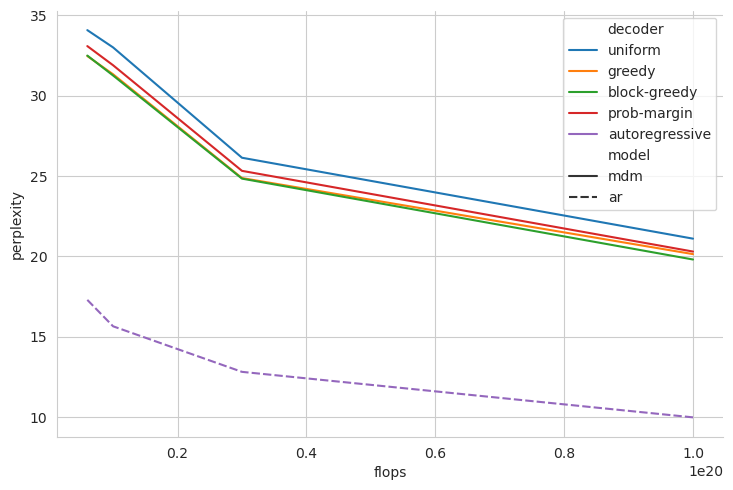

In [7]:
figure = sns.relplot(
    kind="line",
    data=df,
    x="flops",
    y="perplexity",
    hue="decoder",
    style="model",
    aspect=1.5
)

figure._legend.remove()
figure.ax.legend(loc='upper right')  # or 'best', 'upper left', etc.

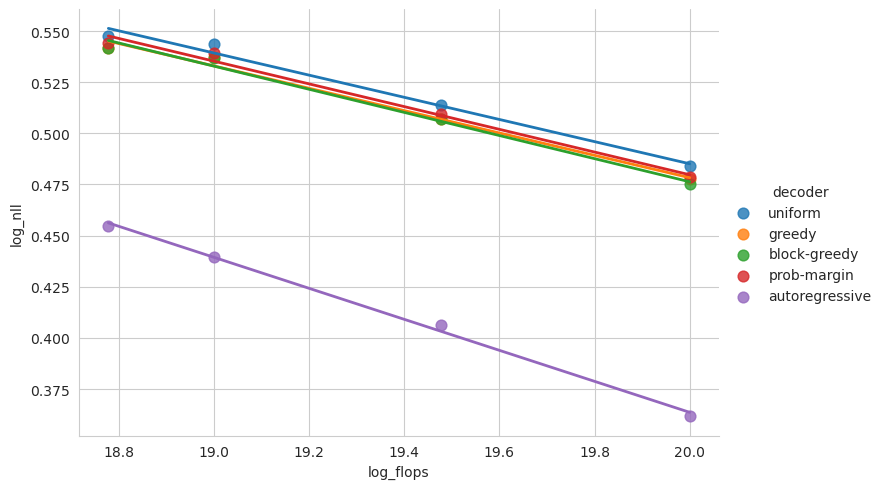

In [22]:
df["log_flops"] = np.log10(df["flops"])
df["log_nll"] = np.log10(df["nll"])

fig = sns.lmplot(
    data=df,
    x="log_flops",
    y="log_nll",
    hue="decoder",
    aspect=1.5,
    ci=None,
    scatter_kws={"alpha": 0.8, "s": 60},
    line_kws={"linewidth": 2},
    facet_kws=dict(sharex=True, sharey=True),
)